In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score , recall_score , classification_report
from sklearn.datasets import load_breast_cancer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
breast_cancer = load_breast_cancer(as_frame=True).frame

df = breast_cancer.copy()
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [16]:
des = df.describe().T
des['Correlation_with_target'] = df.corr(numeric_only=True)['target']
des


,count,mean,std,min,25%,50%,75%,max,Correlation_with_target
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000,-0.730029
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000,-0.415185
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000,-0.742636
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000,-0.708984
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340,-0.358560
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540,-0.596534
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680,-0.696360
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120,-0.776614
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400,-0.330499
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744,0.012838


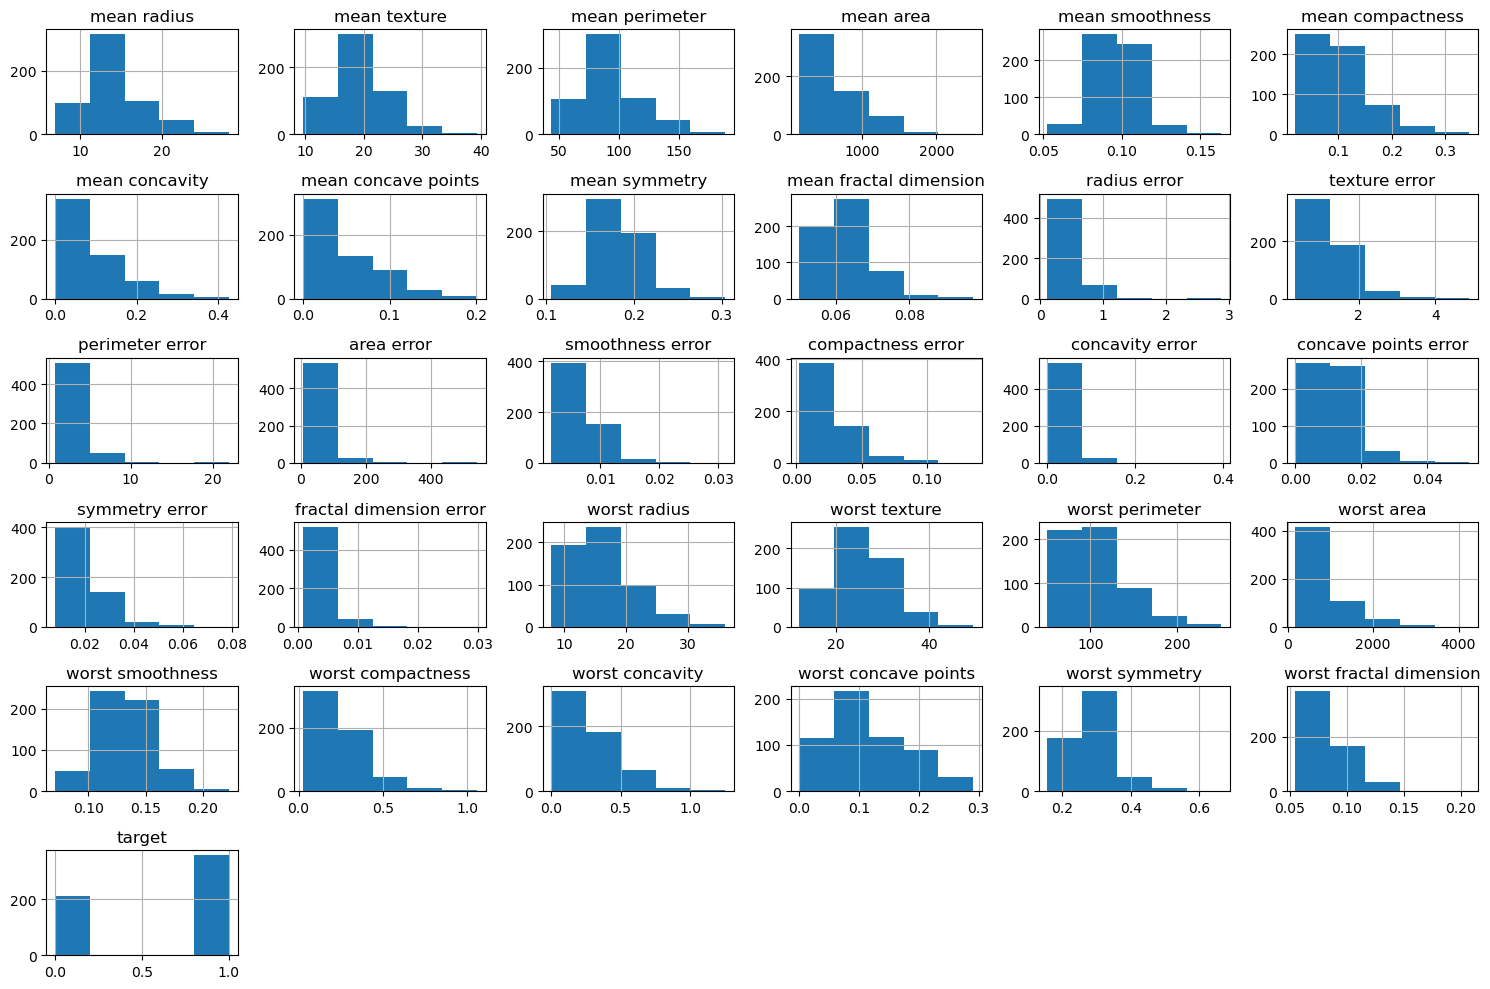

In [20]:
df.hist(bins=5 , figsize=(15,10))
plt.tight_layout()
plt.show()

In [5]:
X = df.drop("target" , axis=1)
y = df["target"]

In [6]:
X_train , X_test , y_train , y_test = train_test_split(
    X , y , random_state=42 , test_size=0.3 , stratify=y
)

pipe = Pipeline([('scalar' , StandardScaler()) , ('svc' , SVC())])
param = {
    'svc__C' : [0.01 , 0.1 , 2, 3 ,4 ,5],
    'svc__kernel' : ['linear' , 'poly' , 'rbf'],
    'svc__gamma' : [0.1 , 0.2 , 0.3 , 1.0 , 2.0 , 3.0]
}

grid = GridSearchCV(
    pipe,
    param,
    scoring='recall',
    cv = 5
    
)

grid.fit(X_train , y_train)

,estimator,"Pipeline(step...svc', SVC())])"
,param_grid,"{'svc__C': [0.01, 0.1, ...], 'svc__gamma': [0.1, 0.2, ...], 'svc__kernel': ['linear', 'poly', ...]}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [7]:
print(grid.best_params_)

{'svc__C': 0.01, 'svc__gamma': 0.1, 'svc__kernel': 'linear'}


In [8]:
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

best_model = SVC(C=0.01 , gamma=0.1 , kernel='linear')
best_model.fit(X_train_scaled , y_train)
y_pred = best_model.predict(X_test_scaled)


print(f"Recall Score: {recall_score(y_pred, y_test)}")
print(f"Accuracy: {accuracy_score(y_pred, y_test)}")
gg

Recall Score: 0.9464285714285714
Accuracy: 0.9590643274853801
